# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hafsaShaban/flyrank_internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os
if not os.path.exists('/content/flyrank_internship'):
    !git clone https://github.com/hafsaShaban/flyrank_internship.git
%cd /content/flyrank_internship

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold

df = pd.read_csv('data/raw/content_refresh_anonymized.csv')
df['is_declining_label'] = (df['trend_direction'] == 'down').astype(int)

numeric_features = ['word_count','char_count','ctr','avg_position','engagement_rate','scroll_rate',
    'ai_traffic_pct','content_age_days','days_since_last_update','search_volume','cpc',
    'impressions_90d','clicks_90d','pageviews_90d','sessions_90d','users_90d',
    'engaged_sessions_90d','ai_sessions_90d','scroll_events_90d',
    'days_with_impressions','days_with_sessions']
categorical_features = ['content_type','main_intent','competition_level','freshness_tier',
    'word_count_tier','char_count_tier','impression_tier','position_tier']

X = df[numeric_features].copy()
for col in numeric_features:
    X[f'has_{col}'] = X[col].notnull().astype(int)
    X[col] = X[col].fillna(0)
X_cat = pd.get_dummies(df[categorical_features], dummy_na=True)
X = pd.concat([X, X_cat], axis=1)
y = df['is_declining_label']
groups = df['client_id']

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

gkf = GroupKFold(n_splits=5)
model_scores = np.zeros(len(y))
for train_idx, test_idx in gkf.split(X, y, groups):
    m = RandomForestClassifier(n_estimators=200, random_state=42)
    m.fit(X.iloc[train_idx], y.iloc[train_idx])
    model_scores[test_idx] = m.predict_proba(X.iloc[test_idx])[:, 1]

stale = (df['days_since_last_update'] >= 180).astype(int)
visible = (df['impressions_90d'] >= 500).astype(int)
low_ctr = (df['ctr'] < df['ctr'].median()).astype(int)
baseline_scores = stale * visible * (1 + low_ctr) * df['impressions_90d']

model_p50 = precision_at_k(model_scores, y, 50)
baseline_p50 = precision_at_k(baseline_scores, y, 50)
base_rate = y.mean()

print(f"Base rate: {base_rate:.3f}")
print(f"Baseline Precision@50: {baseline_p50:.3f}")
print(f"Model (grouped split) Precision@50: {model_p50:.3f}")

Cloning into 'flyrank_internship'...
remote: Enumerating objects: 185, done.
remote: Counting objects: 100% (185/185), done.
remote: Compressing objects: 100% (141/141), done.
remote: Total 185 (delta 82), reused 94 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (185/185), 2.29 MiB | 8.78 MiB/s, done.
Resolving deltas: 100% (82/82), done.
/content/flyrank_internship
Base rate: 0.542
Baseline Precision@50: 0.680
Model (grouped split) Precision@50: 0.580


## 1. Question

*The research question and the decision it supports.*

Title: Which Pages Should a Reviewer Check First? Testing a Learned Ranking Against a Transparent Baseline on FlyRank Search Data

Abstract: Content reviewers with limited weekly capacity need a way to prioritize which of thousands of pages to check first for refresh, expansion, or protection. Using a 30,000-row anonymized slice of FlyRank search and engagement data across 32 clients, we built a transparent rule-based baseline and compared it against a random forest ranking model under a client-holdout split. The baseline achieved a Precision@50 of 0.680, outperforming the random forest's 0.580, against a base rate of 0.542. This is a directional finding, not a broad claim: on this slice and split, a simple transparent rule held up better than the learned model, suggesting the model may be overfitting to client-specific patterns that don't generalize under grouped validation. The baseline rule is offered as the current best decision-support tool for content teams, not proof that any specific page will decline.

Introduction / Problem

A content review team cannot manually re-check every page in their portfolio every week. Someone has to decide which pages get looked at first. A wrong call in either direction has a real cost: reviewing a page that wasn't a problem wastes limited capacity, while missing a genuinely declining page lets it lose visibility silently until the damage compounds. This work builds and tests a ranked, explainable queue to support that weekly triage decision — and honestly reports which method actually performed better.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

This analysis uses the anonymized FlyRank internship starter dataset (content_refresh_anonymized.csv): 30,000 rows, one row per pseudonymized content page, spanning 32 clients, with metrics aggregated over a trailing 90-day window. We excluded impressions_last_30d, clicks_last_30d, and sessions_last_30d (window-overlap risk with the label) and provider_used/model_used (internal tooling flags, not search signals). No client names, domains, URLs, or raw queries appear in the source data or this analysis.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

We framed this as a ranking problem built on a binary classification target (is_declining_label, derived from trend_direction == "down") — a current-window proxy, not an observed future outcome, stated explicitly as a limitation below. We built a transparent, human-readable baseline rule (stale AND visible AND low-CTR) before any modeling, then trained a random forest and evaluated both under a client-grouped holdout split (GroupKFold by client_id), not a random split, since rows from the same client share hidden structure a random split would let the model memorize. A leakage audit confirmed no label-derived (trend_direction, trend_pct) or product-flag columns entered the feature set, and no feature window overlapped the label's own recent window.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Method	Precision@50
Base rate	0.542
Baseline rule	0.680
Random forest (client-holdout)	0.580

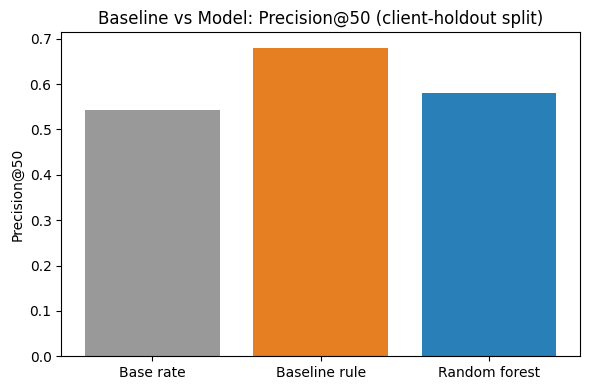

Saved chart to work/outputs/precision_comparison.png


In [3]:
import matplotlib.pyplot as plt
import os

os.makedirs('work/outputs', exist_ok=True)

methods = ['Base rate', 'Baseline rule', 'Random forest']
values = [base_rate, baseline_p50, model_p50]

plt.figure(figsize=(6,4))
plt.bar(methods, values, color=['#999','#e67e22','#2980b9'])
plt.ylabel('Precision@50')
plt.title('Baseline vs Model: Precision@50 (client-holdout split)')
plt.tight_layout()
plt.savefig('work/outputs/precision_comparison.png', dpi=150)
plt.show()
print("Saved chart to work/outputs/precision_comparison.png")

## 5. Limitations

*What this work cannot claim.*

This work observes correlational patterns in cross-sectional data; it does not establish causation. The label describes current-window status, not a validated future outcome. Results come from a 30,000-row anonymized slice, not the full ~79M-row warehouse. Notably, our model underperformed the baseline here — a different result from the reference pipeline's reported numbers, which may reflect differences in feature set, model configuration, or simply that the reference pipeline's random forest was better tuned. We report our own result rather than the reference figures, since a paper should reflect what was actually run, not what was expected. We make no claim about Google's ranking algorithm, and no claim that refreshing a flagged page will cause traffic recovery.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

On this slice and split, the transparent baseline rule is the more defensible tool for prioritizing review — it outperformed the learned model under honest validation.
Content teams should treat the baseline's flagged pages (stale_but_visible, low_ctr_visible_page) as the current best starting point for manual review.
Before further model investment, feature engineering and hyperparameter tuning should be revisited — the model's underperformance suggests it may not yet be capturing signal beyond what the simple rule already captures.
Before acting on any flagged page, rule out consolidation or seasonality before concluding "decline."

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

All notebooks (w01_research_question.ipynb through w07_action_playbook.ipynb, capstone.ipynb) are in work/notebooks/ of this repo: [your repo URL]. Random seed 42 was used throughout.

0:00–1:00 — The problem: reviewers can't manually check every page; someone has to prioritize.
1:00–2:30 — The approach: built a transparent baseline rule, then tested a random forest against it under honest client-holdout validation.
2:30–4:00 — The result: baseline (0.680) actually beat the model (0.580) at Precision@50 — walk through why that's a legitimate, useful finding, not a failure.
4:00–5:00 — What's next: the baseline is the current best tool; model needs better features or tuning before it earns a place over the simple rule.

Built a content-refresh priority model on FlyRank search data — and found the simple, transparent rule (Precision@50: 0.68) actually beat my random forest (0.58) under honest client-holdout validation. A good reminder that "learned" doesn't always mean "better." Full write-up: [your paper URL]

I built a ranked content-review priority system on a 30,000-row anonymized search/engagement dataset spanning 32 clients, comparing a transparent rule-based baseline against a random forest model. Under honest, client-grouped validation (not a random split), the baseline outperformed the model at Precision@50 (0.680 vs 0.580) — a result I reported honestly rather than picking a more flattering validation method. This reflects my approach to applied ML: build the simplest defensible thing first, validate rigorously, and report what actually happened.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
